# Problem 9.3 Predicting Prices of Used Cars (Regression Trees). 

The dataset __ToyotaCorolla.csv__ contains the data on used cars (Toyota Corolla) on sale during late summer of 2004 in the Netherlands. It has 1436 records containing details on 38 attributes, including Price, Age, Kilometers, HP, and other specifications. The goal is to predict the price of a used Toyota Corolla based on its specifications. (The example in Section 9.7 is a subset of this dataset).

In [1]:
!python --version
#!pip install mlba

Python 3.13.5


In [2]:
import mlba
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import plot_tree, DecisionTreeClassifier, DecisionTreeRegressor
import matplotlib.pylab as plt

%matplotlib inline

__9.3.a.__ Run a full-grown regression tree (RT) with outcome variable Price and predictors Age_08_04, KM, Fuel_Type (first convert to dummies), HP, Automatic, Doors, Quarterly_Tax, Mfr_Guarantee, Guarantee_Period, Airco, Automatic_airco, CD_Player, Powered_Windows, Sport_Model, and Tow_Bar. Set random_state=1.

__9.3.a.i.__ Which appear to be the three or four most important car specifications for predicting the car’s price?

In [3]:
car_df = mlba.load_data('ToyotaCorolla.csv')

columns = [
    "Price",
    "Age_08_04",
    "KM",
    "Fuel_Type",
    "HP",
    "Automatic",
    "Doors",
    "Quarterly_Tax",
    "Mfr_Guarantee",
    "Guarantee_Period",
    "Airco",
    "Automatic_airco",
    "CD_Player",
    "Powered_Windows",
    "Sport_Model",
    "Tow_Bar",
]

car_df = car_df[columns]

car_df = pd.get_dummies(car_df, drop_first=True)

car_df.head()

,Price,Age_08_04,KM,HP,Automatic,Doors,Quarterly_Tax,Mfr_Guarantee,Guarantee_Period,Airco,Automatic_airco,CD_Player,Powered_Windows,Sport_Model,Tow_Bar,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,3,210,0,3,0,0,0,1,0,0,True,False
1,13750,23,72937,90,0,3,210,0,3,1,0,1,0,0,0,True,False
2,13950,24,41711,90,0,3,210,1,3,0,0,0,0,0,0,True,False
3,14950,26,48000,90,0,3,210,1,3,0,0,0,0,0,0,True,False
4,13750,30,38500,90,0,3,210,1,3,1,0,0,1,0,0,True,False


In [4]:
X = car_df.drop(columns=["Price"])
y = car_df['Price']

train_X, holdout_X, train_y, holdout_y = train_test_split(X, y, test_size = 0.4, random_state = 1)

print(f"Train shape: {train_X.shape}, {train_y.shape}")
print(f"Holdout shape: {holdout_X.shape}, {holdout_y.shape}")

Train shape: (861, 16), (861,)
Holdout shape: (575, 16), (575,)


743


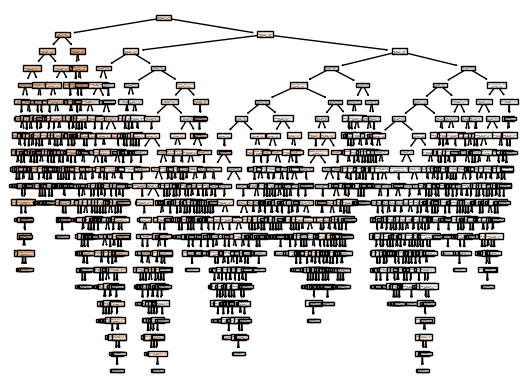

In [5]:
# Make decision tree
reg_tree = DecisionTreeRegressor(random_state=1)
reg_tree.fit(train_X, train_y)

print(reg_tree.get_n_leaves()) # a lot of leaves

plot_tree(reg_tree, feature_names=train_X.columns, impurity=False, filled=True)
plt.show()

In [6]:
#importances = reg_tree.feature_importances_
#print(importances)
importances = pd.DataFrame({'features': train_X.columns, 'importance' : reg_tree.feature_importances_})
importances = importances.sort_values('importance', ascending=False)
importances

,features,importance
0,Age_08_04,0.844867
2,HP,0.053789
1,KM,0.049601
9,Automatic_airco,0.013358
5,Quarterly_Tax,0.006769
11,Powered_Windows,0.005221
4,Doors,0.004864
8,Airco,0.004727
12,Sport_Model,0.004459
6,Mfr_Guarantee,0.003714


The top 4 most important features for predicting car prices are Age_08_04, KM, HP, and Automatic_airco.

__9.3.a.ii.__ Compare the prediction errors of the training and holdout sets by examining their RMS error and by plotting the two boxplots. How does the predictive performance of the holdout set compare to the training set? Why does this occur?

In [7]:
results = pd.DataFrame({'training': mlba.regressionMetrics(y_true=train_y, y_pred=reg_tree.predict(train_X)),
                        'holdout': mlba.regressionMetrics(y_true=holdout_y, y_pred=reg_tree.predict(holdout_X)), 
                      }).transpose().round(3)
print(results)

              ME      RMSE       MAE    MPE    MAPE
training   0.000     0.000     0.000  0.000   0.000
holdout   76.656  1492.336  1152.485 -0.336  11.378


The training data is so complex and deep (many leaf node layers) and that the errors being 0 across the metrics showing that every record is being predicted accurately. 

__9.3.a.iii.__ How might we achieve better holdout predictive performance at the expense of training performance? #I am not sure I need to study this!

We can do a few things. One of them is limiting tree growth, the tree is too big and is overfitting which is why it predicts the training data so accurately, using GridSearch and Cross Validation.  

__9.3.a.iv.__ Create a smaller tree by using GridSearchCV() with cv=5 to find a fine-tuned tree. Compared to the full-grown tree, what is the predictive performance on the holdout set?

In [8]:
param_grid = {
    'max_depth': [10, 20, 30],
    'min_samples_split': [20,40,60],
}
gridSearch = GridSearchCV(DecisionTreeRegressor(random_state=1),
            param_grid, cv=5, n_jobs=-1) #n-jobs will use all available CPU power
gridSearch.fit(train_X, train_y)


GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=1), n_jobs=-1,
             param_grid={'max_depth': [10, 20, 30],
                         'min_samples_split': [20, 40, 60]})

In [9]:
print(f'Initial score: {gridSearch.best_score_:.4f}')
print(f'Initial parameters: , {gridSearch.best_params_}')

Initial score: 0.8636
Initial parameters: , {'max_depth': 10, 'min_samples_split': 20}


In [10]:
optimal_reg_tree = gridSearch.best_estimator_
importance_rt = pd.DataFrame({'feature': train_X.columns, 'importance': optimal_reg_tree.feature_importances_})
optimal_reg_tree.get_n_leaves()

np.int64(81)

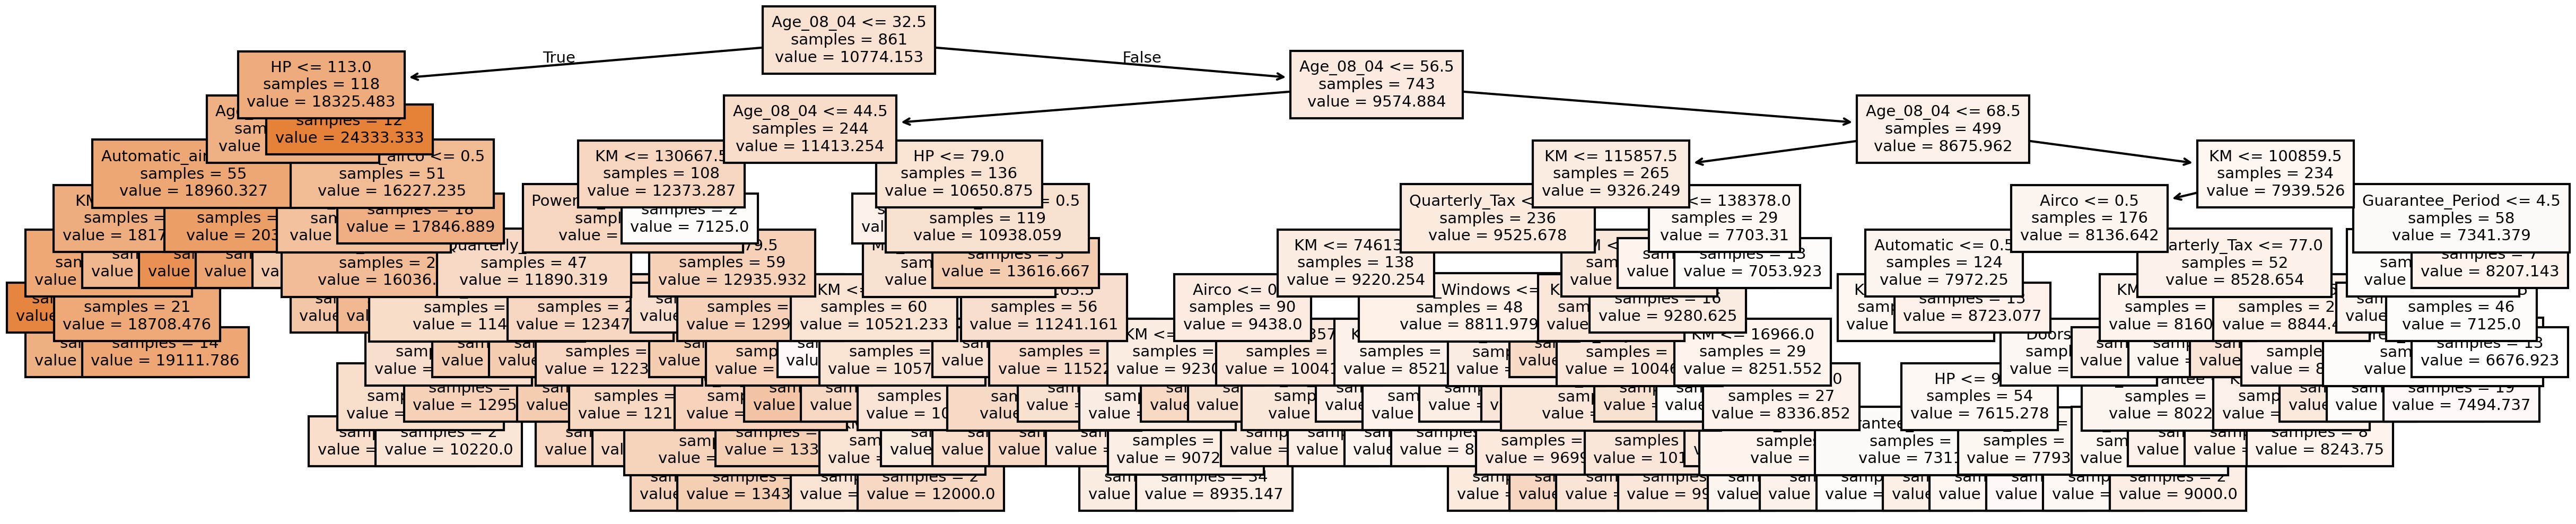

In [11]:
plt.figure(figsize=[20,4], dpi=300)

plot_tree(optimal_reg_tree, feature_names=train_X.columns, impurity=False, filled=True, fontsize=7)
plt.show()

In [12]:
#error of optimal tree
pd.DataFrame({'training': mlba.regressionMetrics(y_true=train_y, y_pred=optimal_reg_tree.predict(train_X)),
              'holdout': mlba.regressionMetrics(y_true=holdout_y, y_pred=optimal_reg_tree.predict(holdout_X))
            }).transpose().round(3)

,ME,RMSE,MAE,MPE,MAPE
training,0.000,970.253,667.026,-0.757,6.372
holdout,-2.255,1285.483,974.561,-1.232,9.646


In [16]:
#Use randomizedSearch
import scipy
from sklearn.model_selection import RandomizedSearchCV

In [18]:
param_dist = {
     "max_depth": list(range(1,25)),
     "min_impurity_decrease": scipy.stats.expon(scale=1),
     "min_samples_split": list(range(2,50)),
 }

randomSearch = RandomizedSearchCV(
    DecisionTreeRegressor(random_state=1), param_dist, cv=5, n_iter=200, n_jobs=-1, random_state=1)
randomSearch.fit(train_X, train_y)
randomSearch.best_params_

{'max_depth': 7,
 'min_impurity_decrease': np.float64(0.040492363506326005),
 'min_samples_split': 7}

__9.3.b.__ Let us see the effect of turning the price variable into a categorical variable. First, create a new variable that categorizes price into 20 bins. Now repartition the data keeping Binned_Price instead of Price. Run a classification tree with the same set of input variables as in the RT, and with Binned_Price as the output variable. As in the less deep regression tree, create a smaller tree by using GridSearchCV() with cv=5 to find a fine-tuned tree.

In [29]:
#Let us see the effect of turning the price variable into a categorical variable. 
#First, create a new variable that categorizes price into 20 bins. 
car_df['binned_price'] = pd.cut(car_df['Price'], 20, labels=False)
car_df.head(5)

X = car_df.drop(columns=['Price', 'binned_price'])
y = car_df["binned_price"]

train_X, holdout_X, train_y, holdout_y = train_test_split(X, y, test_size=0.4, random_state=1)
                        

In [30]:
param_dist = {
     "max_depth": list(range(1,25)),
     "min_impurity_decrease": scipy.stats.expon(scale=1),
     "min_samples_split": list(range(2,50)),
 }

randomSearch = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=1),
    param_dist,
    cv=5,
    n_iter=200,
    n_jobs=-1,
    random_state=1,
)
randomSearch.fit(train_X, train_y)
print(randomSearch.best_params_)

optClassTree = randomSearch.best_estimator_

importanceCT = pd.DataFrame(
    {"features": train_X.columns, "importance": optClassTree.feature_importances_}
)

C:\Users\samsc\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


{'max_depth': 14, 'min_impurity_decrease': np.float64(0.0030225198340434697), 'min_samples_split': 23}


In [31]:
optClassTree.get_n_leaves()

np.int64(25)

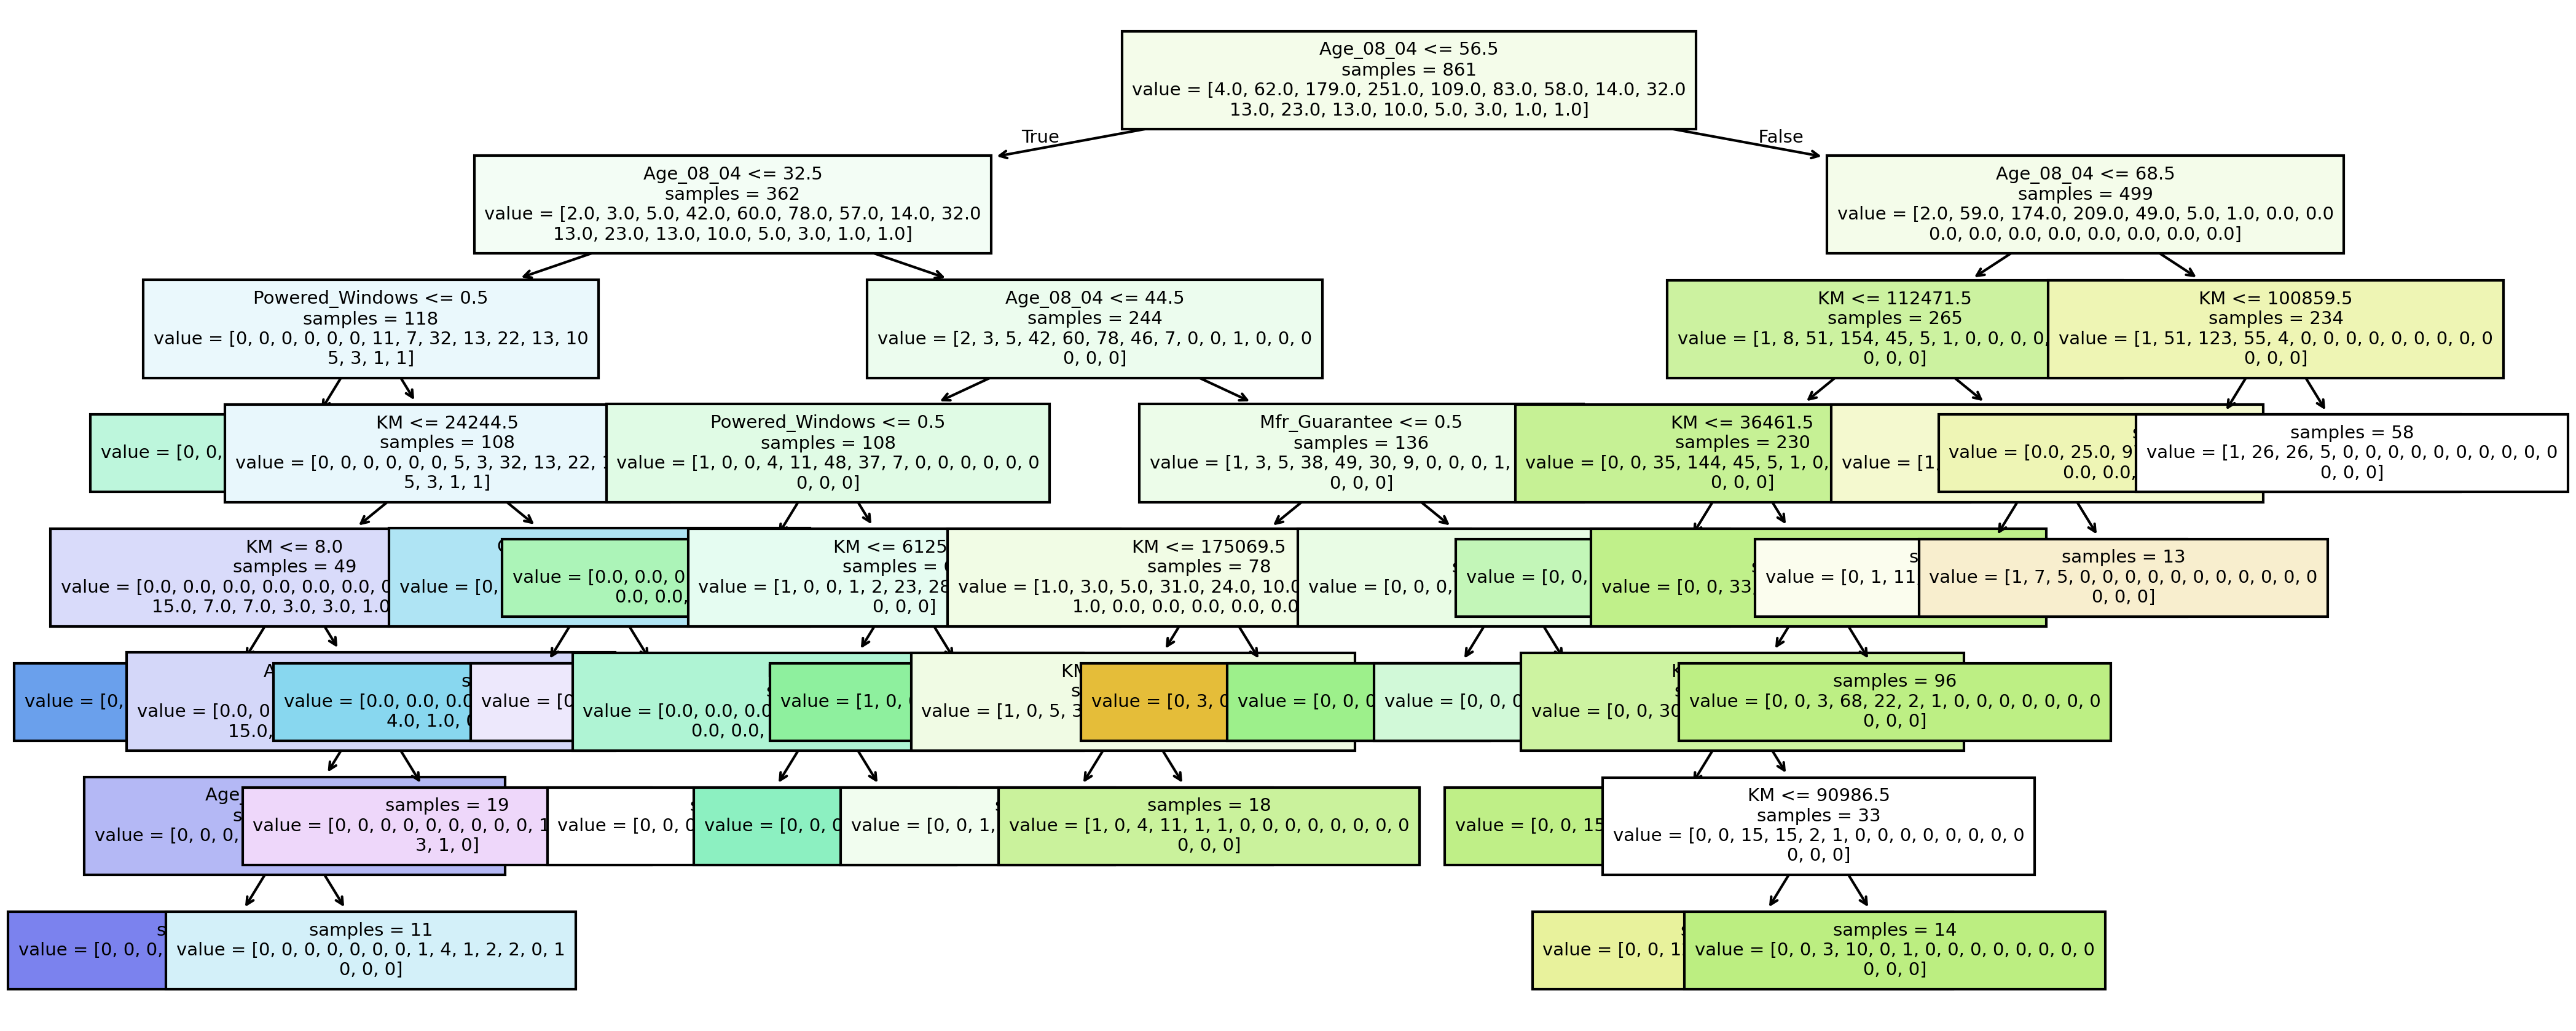

In [32]:
plt.figure(figsize=[16,7], dpi=300)
plot_tree(optClassTree, feature_names=train_X.columns, impurity=False, filled=True, fontsize=7)
plt.show()

In [34]:
mlba.classificationSummary(y_true=train_y, y_pred=optClassTree.predict(train_X))

Confusion Matrix (Accuracy 0.5668)

       Prediction
Actual   0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  18  19
     0   0   2   0   1   0   1   0   0   0   0   0   0   0   0   0   0   0
     1   0  36  26   0   0   0   0   0   0   0   0   0   0   0   0   0   0
     2   0  31 120  25   3   0   0   0   0   0   0   0   0   0   0   0   0
     3   0   5  65 144  30   7   0   0   0   0   0   0   0   0   0   0   0
     4   0   0   6  33  48  22   0   0   0   0   0   0   0   0   0   0   0
     5   0   0   0   5  13  56   9   0   0   0   0   0   0   0   0   0   0
     6   0   0   0   1   3  20  29   0   2   0   0   3   0   0   0   0   0
     7   0   0   0   0   0   6   5   0   3   0   0   0   0   0   0   0   0
     8   0   0   0   0   0   0   0   0  29   0   0   3   0   0   0   0   0
     9   0   0   0   0   0   0   0   0   5   4   1   2   1   0   0   0   0
    10   0   0   0   0   1   0   0   0   6   0  10   3   3   0   0   0   0
    11   0   0   0   0   0   0   0   0   3   0

In [35]:
mlba.classificationSummary(y_true=holdout_y, y_pred=optClassTree.predict(holdout_X))

Confusion Matrix (Accuracy 0.4487)

       Prediction
Actual  0  1  2  3  4  5  6  7  8  9 10 11 12 14 19
     0  0  6  0  1  0  1  0  0  0  0  0  0  0  0  0
     1  0 11 19  5  0  1  0  0  0  0  0  0  0  0  0
     2  0 24 59 29  0  1  0  0  0  0  0  0  0  0  0
     3  0 11 51 78 20  4  0  0  0  0  0  0  0  0  0
     4  0  1  5 31 26 16  2  0  0  0  0  0  0  0  0
     5  0  0  0  2 13 46  8  0  0  0  0  0  0  0  0
     6  0  0  0  0  4 15 13  0  0  0  0  0  0  0  0
     7  0  0  0  0  0  2  3  0  5  0  0  0  0  0  0
     8  0  0  0  0  0  0  1  0 18  0  0  1  0  0  0
     9  0  0  0  0  0  0  0  0  5  1  0  2  2  0  0
    10  0  0  0  0  0  0  0  0  5  0  4  2  5  0  0
    11  0  0  0  0  0  0  0  0  0  0  1  1  5  0  0
    12  0  0  0  0  0  0  0  0  2  0  0  4  1  0  0
    14  0  0  0  0  0  0  0  0  0  0  0  0  1  0  0
    19  0  0  0  0  0  0  0  0  0  0  0  0  1  0  0


With this new tree our performance is similar to the regression tree. 

In [37]:
importanceCT = importanceCT.sort_values('importance', ascending=False)
importanceCT

,features,importance
0,Age_08_04,0.636643
1,KM,0.222272
11,Powered_Windows,0.039683
6,Mfr_Guarantee,0.021692
5,Quarterly_Tax,0.019062
8,Airco,0.017839
2,HP,0.016134
9,Automatic_airco,0.015025
4,Doors,0.011650
3,Automatic,0.000000


In [38]:
importance_rt

,feature,importance
0,Age_08_04,0.878956
1,KM,0.030645
2,HP,0.053344
3,Automatic,0.000743
4,Doors,0.001348
5,Quarterly_Tax,0.004546
6,Mfr_Guarantee,0.001659
7,Guarantee_Period,0.001822
8,Airco,0.004252
9,Automatic_airco,0.014034


__9.3.b.ii.__ Predict the price, using the smaller RT and CT, of a used Toyota Corolla with the specifications listed in Table 9.10.

In [41]:
useCar_df = pd.DataFrame(
    [
        {
            "Age_08_04": 77,
            "KM": 117000,
            "Fuel_Type_Petrol": 1,
            "Fuel_Type_Diesel": 0,
            "HP": 110, 
            "Automatic": 0,
            "Doors": 5,
            "Quarterly_Tax": 100,
            "Mfr_Guarantee": 0,
            "Guarantee_Period": 3,
            "Airco": 1,
            "Automatic_airco": 0, 
            "CD_Player": 0, 
            "Powered_Windows": 0, 
            "Sport_Model": 0,
            "Tow_Bar": 1,
        }
    ]
)

useCar_df = useCar_df[optimal_reg_tree.feature_names_in_]

print(optimal_reg_tree.predict(useCar_df))

[7039.28571429]
